# Adaptive RAG

## Definition

**Adaptive RAG (Retrieval-Augmented Generation)** is a framework that dynamically adjusts its strategy for handling queries based on their complexity.

Instead of using a single, rigid retrieval approach for every question, Adaptive RAG chooses the most appropriate strategy for each query. It can determine whether a query is related to the available knowledge base, whether retrieval is required, whether web search should be used, and whether the generated answer needs further refinement.

In simple terms, **Adaptive RAG acts like an intelligent routing system that decides how much information retrieval and reasoning a query needs before producing the final answer.**

## How Adaptive RAG Works with LangGraph

1. **Receive the Question:** The workflow receives the user's query.
2. **Analyze the Query:** The `Query Analysis` node determines the nature of the query and decides how it should be handled.
3. **Route the Query:** Based on the analysis, the query is routed to the appropriate path.
4. **Related to the Index:** If the query is related to the available knowledge base, the workflow uses the RAG + self-reflection path.
5. **Retrieve Documents:** The `Retrieve` node retrieves relevant documents.
6. **Grade Documents:** The `Grade` node evaluates whether the retrieved documents are relevant.
7. **Generate the Answer:** If the documents are relevant, the `Generate` node generates an answer.
8. **Check for Hallucinations:** The generated answer can be evaluated to determine whether it contains hallucinations.
9. **Check Answer Relevance:** The workflow checks whether the generated answer actually addresses the question.
10. **Rewrite the Query:** If the documents or generated answer are not satisfactory, the query can be rewritten and the retrieval process repeated.
11. **Unrelated to the Index:** If the query is unrelated to the available knowledge base, the workflow can use web search instead.
12. **Generate with Web Search:** The retrieved web information is used to generate the final answer.
13. **Optional Routes:** Additional routes can be added depending on the requirements of the application.

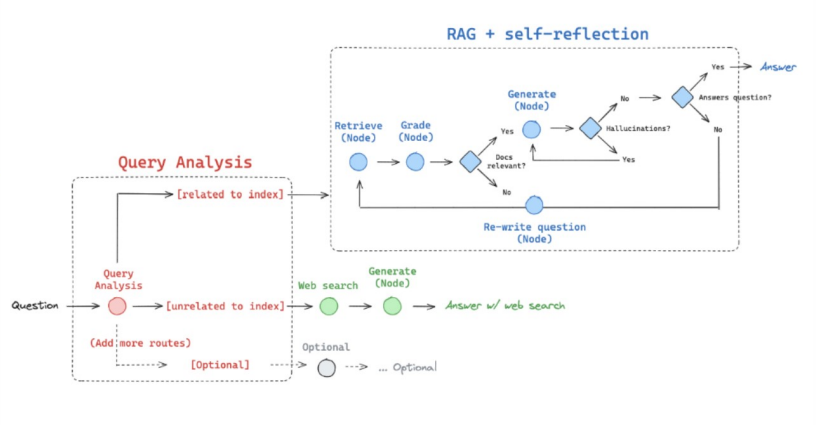

## Benefits of Adaptive RAG

- **Dynamic Retrieval:** Chooses the most appropriate retrieval strategy based on the query.
- **Improved Accuracy:** Uses deeper retrieval and self-reflection when needed.
- **Better Efficiency:** Avoids unnecessary retrieval for simple or unrelated queries.
- **Reduced Hallucinations:** Evaluates generated answers and can take corrective actions.
- **Flexible Routing:** Supports different paths such as vector retrieval, query rewriting, and web search.

## Setting Up the Environment

In [1]:
### Loading Environment Variables
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN')
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

## Building the Vector Store

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

### from langchain_cohere import CohereEmbeddings

### Creating Hugging Face Embeddings
embd = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

# Docs to index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

### Loading Documents
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

### Splitting Documents into Chunks
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs_list)

### Creating the FAISS Vector Store
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=embd
)

### Creating the Retriever
retriever=vectorstore.as_retriever()

C:\Users\devgo\AppData\Local\Temp\ipykernel_8576\1921632963.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
d:\agentic-ai\02-LangGraph\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1392.07it/s]


## Building the Query Router

In [3]:
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field

### Creating the Routing Model
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource."""

    datasource: Literal["vectorstore", "web_search"] = Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorstore.",
    )

# LLM with structured output
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)
structured_llm_router = llm.with_structured_output(RouteQuery)

### Creating the Routing Prompt
system = """You are an expert at routing a user question to a vectorstore or web search.
The vectorstore contains documents related to agents, prompt engineering, and adversarial attacks.
Use the vectorstore for questions on these topics. Otherwise, use web-search."""

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

### Routing the User Query
question_router = route_prompt | structured_llm_router

print(
    question_router.invoke(
        {"question": "Who won the Cricket world cup 2023 "}
    )
)

datasource='web_search'


In [4]:
print(question_router.invoke({"question": "What are the types of agent memory?"}))

datasource='vectorstore'


## Building the Retrieval Grader

In [5]:
### Creating the Grading Model
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# LLM with structured output
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

### Creating the Grading Prompt
system = """You are a grader assessing relevance of a retrieved document to a user question.

If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant.

It does not need to be a stringent test. The goal is to filter out erroneous retrievals.

Give a binary score 'yes' or 'no' to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

### Grading the Retrieved Documents
retrieval_grader = grade_prompt | structured_llm_grader

question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content

print(
    retrieval_grader.invoke(
        {"question": question, "document": doc_txt}
    )
)

binary_score='yes'


## Building the RAG Generator

In [6]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate

### Creating the RAG Prompt
prompt = PromptTemplate.from_template(
    """You are an assistant for question-answering tasks.

Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use three sentences maximum and keep the answer concise.

Question: {question}

Context: {context}

Answer:"""
)

# LLM
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)

# Post-processing
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

# Chain
rag_chain = prompt | llm | StrOutputParser()

# Run
generation = rag_chain.invoke(
    {"context": format_docs(docs), "question": question}
)
print(generation)

Agent memory in LLM-powered autonomous systems consists of short-term memory, which utilizes in-context learning, and long-term memory, which retains information over extended periods using external vector stores. Long-term memory often employs retrieval models that surface relevant context based on recency, importance, and relevance to the current situation. Additionally, reflection mechanisms can synthesize these memories into higher-level inferences to guide the agent's future behavior.


## Building the Hallucination Grader

In [7]:
### Creating the Hallucination Grader Model
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

# LLM with structured output
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# Prompt
system = """You are a grader assessing whether an LLM generation is grounded in / supported by a set of retrieved facts.

Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in / supported by the set of facts."""

hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

hallucination_grader = hallucination_prompt | structured_llm_grader
hallucination_grader.invoke({"documents": docs, "generation": generation})

GradeHallucinations(binary_score='yes')

## Building the Answer Grader

In [8]:
### Creating the Answer Grader Model
class GradeAnswer(BaseModel):
    """Binary score to assess answer addresses question."""

    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )

# LLM with structured output
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# Prompt
system = """You are a grader assessing whether an answer addresses / resolves a question.

Give a binary score 'yes' or 'no'. 'Yes' means that the answer resolves the question."""

answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

answer_grader = answer_prompt | structured_llm_grader
answer_grader.invoke({"question": question, "generation": generation})

GradeAnswer(binary_score='yes')

## Building the Question Rewriter

In [9]:
# LLM
llm = ChatGroq(model="qwen/qwen3.8-27b", temperature=0)

# Prompt
system = """You are a question re-writer that converts an input question to a better version that is optimized
for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'How does agent memory function, and what are its key components and mechanisms for storing and retrieving information?'

## Setting Up Web Search

In [10]:
from langchain_community.tools.tavily_search import TavilySearchResults

web_search_tool = TavilySearchResults(k=3)

C:\Users\devgo\AppData\Local\Temp\ipykernel_8576\1505316070.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  web_search_tool = TavilySearchResults(k=3)


## Defining the Graph State

In [11]:
from typing import List
from typing_extensions import TypedDict
from langchain_core.documents import Document


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        documents: list of documents
    """

    question: str
    generation: str
    documents: List[Document]

## Creating the Adaptive RAG Nodes

### Creating the Retrieval Node

In [12]:
def retrieve(state):
    """
    Retrieve documents.
    """
    print("---RETRIEVE---")
    question = state["question"]

    documents = retriever.invoke(question)

    return {"documents": documents, "question": question}

### Creating the Generation Node

In [13]:
def generate(state):
    """
    Generate answer.
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    generation = rag_chain.invoke(
        {
            "context": format_docs(documents),
            "question": question,
        }
    )

    return {
        "documents": documents,
        "question": question,
        "generation": generation,
    }

### Creating the Document Grading Node

In [14]:
def grade_documents(state):
    """
    Determine whether the retrieved documents are relevant to the question.
    """
    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")

    question = state["question"]
    documents = state["documents"]

    filtered_docs = []

    for d in documents:
        score = retrieval_grader.invoke(
            {
                "question": question,
                "document": d.page_content,
            }
        )

        grade = score.binary_score

        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")

    return {
        "documents": filtered_docs,
        "question": question,
    }

### Creating the Query Transformation Node

In [15]:
def transform_query(state):
    """
    Transform the query to produce a better question.
    """
    print("---TRANSFORM QUERY---")

    question = state["question"]
    documents = state["documents"]

    better_question = question_rewriter.invoke(
        {"question": question}
    )

    return {
        "documents": documents,
        "question": better_question,
    }

### Creating the Web Search Node

In [16]:
def web_search(state):
    """
    Perform web search based on the question.
    """
    print("---WEB SEARCH---")

    question = state["question"]

    docs = web_search_tool.invoke({"query": question})

    web_results = "\n".join([d["content"] for d in docs])

    web_document = Document(page_content=web_results)

    return {
        "documents": [web_document],
        "question": question,
    }

## Creating the Routing Functions/Edges

### Routing the User Query

In [17]:
def route_question(state):
    """
    Route question to web search or RAG.
    """
    print("---ROUTE QUESTION---")

    question = state["question"]

    source = question_router.invoke(
        {"question": question}
    )

    if source.datasource == "web_search":
        print("---ROUTE QUESTION TO WEB SEARCH---")
        return "web_search"

    elif source.datasource == "vectorstore":
        print("---ROUTE QUESTION TO RAG---")
        return "vectorstore"

### Deciding Whether to Generate or Transform the Query

In [18]:
def decide_to_generate(state):
    """
    Determine whether to generate an answer or transform the question.
    """
    print("---ASSESS GRADED DOCUMENTS---")

    filtered_documents = state["documents"]

    if not filtered_documents:
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"

    else:
        print("---DECISION: GENERATE---")
        return "generate"

### Checking the Generated Answer

In [19]:
def grade_generation_v_documents_and_question(state):
    """
    Determine whether the generation is grounded in the documents
    and answers the question.
    """
    print("---CHECK HALLUCINATIONS---")

    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]

    score = hallucination_grader.invoke(
        {
            "documents": format_docs(documents),
            "generation": generation,
        }
    )

    grade = score.binary_score

    if grade == "yes":
        print("---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---")

        print("---GRADE GENERATION vs QUESTION---")

        score = answer_grader.invoke(
            {
                "question": question,
                "generation": generation,
            }
        )

        grade = score.binary_score

        if grade == "yes":
            print("---DECISION: GENERATION ADDRESSES QUESTION---")
            return "useful"

        else:
            print("---DECISION: GENERATION DOES NOT ADDRESS QUESTION---")
            return "not useful"

    else:
        print(
            "---DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY---"
        )
        return "not supported"

## Building the Adaptive RAG Workflow

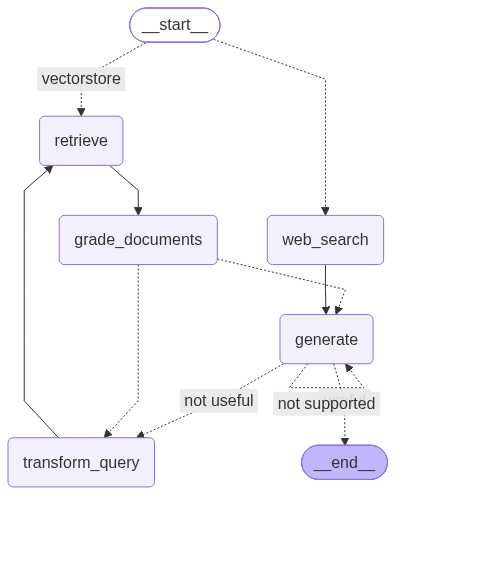

In [20]:
from langgraph.graph import END, StateGraph, START

### Creating the State Graph
workflow = StateGraph(GraphState)

### Adding the Nodes to the Graph
workflow.add_node("web_search", web_search)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("transform_query", transform_query)

### Adding the Edges and Conditional Routing
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search": "web_search",
        "vectorstore": "retrieve",
    },
)

workflow.add_edge("web_search", "generate")
workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)

workflow.add_edge("transform_query", "retrieve")

workflow.add_conditional_edges(
    "generate",
    grade_generation_v_documents_and_question,
    {
        "not supported": "generate",
        "useful": END,
        "not useful": "transform_query",
    },
)

### Compiling the Graph
app = workflow.compile()

### Visualizing the Workflow
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

## Running the Adaptive RAG Application

In [21]:
app.invoke({"question":"What is machine learning"})

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'What is machine learning',
 'generation': 'Machine learning is a subfield of artificial intelligence that enables computer systems to learn from data and improve their performance without being explicitly programmed. It utilizes statistical algorithms to identify patterns and make predictions or decisions, allowing machines to generalize to unseen data. This technology powers various applications, including chatbots, autonomous vehicles, and medical diagnostics.',
 'documents': [Document(metadata={}, page_content='Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks "Task (computing)") without being explicitly programmed.\n\nStatistics and mathematical optimisation methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsu

In [22]:
app.invoke({"question":"Who is Doctor Doom?"})

---ROUTE QUESTION---
---ROUTE QUESTION TO WEB SEARCH---
---WEB SEARCH---
---GENERATE---
---CHECK HALLUCINATIONS---
---DECISION: GENERATION IS GROUNDED IN DOCUMENTS---
---GRADE GENERATION vs QUESTION---
---DECISION: GENERATION ADDRESSES QUESTION---


{'question': 'Who is Doctor Doom?',
 'generation': 'Doctor Doom is the alter ego of Victor von Doom, a brilliant scientist, sorcerer, and the megalomaniacal ruler of the fictional nation of Latveria. He is the primary archenemy of the Fantastic Four, particularly Reed Richards, whom he has rivaled since their college days. In the Marvel Cinematic Universe, the character is portrayed by Robert Downey Jr.',
 'documents': [Document(metadata={}, page_content='Doctor Doom is Victor von Doom, the brilliant scientist, sorcerer and ruler of the fictional nation of Latveria. His greatest rival is Reed\n## Trivia[]\n\n   In the comics, Doctor Doom is the king of Latveria and the archenemy of the Fantastic Four, primarily Reed Richards. He and Richards have been rivals since their time in college, during which he used his mastery over science and sorcery to create a transdimensional machine but ignored Richards\' attempt at fixing a small mistake and the machine exploded in Doom\'s face. Scarred 